# Johansen CO2 Sequestration — Surveillance Well Selection

This notebook scores **all pre-existing drilled wells** (including active injectors) for their
suitability as CO2 surveillance wells using a **multi-criteria framework**.

## Industry-Standard Approach for Dual-Use Injector / Monitor Wells

Injectors accumulate CO2 by design during injection, so raw saturation signals are meaningless
during the injection period. The industry standard (DNV-RP-J203, IEA-GHG Best Practice) is:

> **Post-Injection Monitoring (PIM):** After an injector stops, it is converted to a pressure
> and saturation monitor. Surveillance criteria are evaluated **only from the injection-end year**
> onwards, detecting CO2 arriving from OTHER injectors' plumes or returning CO2.

This levels the playing field: all wells — pure monitors and post-injection mode injectors —
are compared on the same physical basis.

**Excluded from Goal 1** (not pre-existing drilled wells):
- `SBoundary_test_well` — fictional boundary sentinel
- `SBoundary_test_well_2` — fictional boundary sentinel

**Goal 2 (final cell):** The two sentinel wells are added to the radar chart for reference comparison.

**Five evaluation criteria:**
1. Earliest CO2 detection (sensitivity) — post-inj adjusted for injectors
2. Pressure signal strength (detectability) — post-inj baseline for injectors
3. Layer of first detection (buoyancy sensitivity)
4. Consistency across BO runs (robustness)
5. Structural position / depth (updip proximity)

In [57]:
# === PARAMETERS — change only here ===
from pathlib import Path

DATA_ROOT             = Path("/Users/apple/Desktop/study/programming/Matlab/Plugins/MRST-2026a/core/examples/data/Johansen/well_csvs")
SENTINEL_WELLS        = ["SBoundary_test_well", "SBoundary_test_well_2"]  # excluded from Goal 1
KNOWN_INJECTORS_CSV   = ["31_01_01", "31_1-3_S", "31_2-5", "31_05_07", "31_07_01"]
S_DETECTION_THRESHOLD = 0.001    # CO2 saturation to count as 'detected'
S_OWN_CO2_FLOOR       = 0.20     # injectors have residual own CO2 — only count EXCESS above this as plume
P_FRACTURE_BAR        = 380      # caprock fracture pressure [bar]
LAYERS                = [6, 7, 8, 9, 10]

# Auto-detect candidates from the latest run folder (all pre-existing wells, excl. sentinels)
latest_run_folder = sorted([d for d in DATA_ROOT.iterdir() if d.is_dir() and not d.name.startswith('.')])[-1]
all_csv_wells = [f.stem for f in latest_run_folder.glob("*.csv")]
CANDIDATES = sorted([w for w in all_csv_wells if w not in SENTINEL_WELLS])

def is_injector(well_stem):
    return well_stem in KNOWN_INJECTORS_CSV

WEIGHTS = {
    "detection_speed":     0.30,
    "pressure_signal":     0.25,
    "buoyancy_layer":      0.20,
    "consistency":         0.15,
    "structural_position": 0.10,
}

inj_cands = [w for w in CANDIDATES if is_injector(w)]
mon_cands = [w for w in CANDIDATES if not is_injector(w)]
print(f"Parameters loaded.")
print(f"All candidates ({len(CANDIDATES)} wells): {CANDIDATES}")
print(f"  Injectors → post-inj monitoring mode: {inj_cands}")
print(f"  Pure monitors:                        {mon_cands}")

Parameters loaded.
All candidates (7 wells): ['31_01_01', '31_05_02', '31_05_07', '31_07_01', '31_1-3_S', '31_2-5', '31_4-3']
  Injectors → post-inj monitoring mode: ['31_01_01', '31_05_07', '31_07_01', '31_1-3_S', '31_2-5']
  Pure monitors:                        ['31_05_02', '31_4-3']


## Section 0 — Data Ingestion

Load all simulation runs. Extract per-well depth from `Depth_m_Lk` columns. Print a depth-ranked table.

In [58]:
import re, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from scipy.interpolate import interp1d

warnings.filterwarnings('ignore')
matplotlib.rcParams.update({'figure.dpi': 130, 'font.family': 'DejaVu Sans',
                            'axes.spines.top': False, 'axes.spines.right': False})

SAT_COLS = [f'S_CO2_L{k}' for k in LAYERS]
PRE_COLS = [f'P_bar_L{k}' for k in LAYERS]
DEP_COLS = [f'Depth_m_L{k}' for k in LAYERS]

def parse_injector_end_times(txt_path):
    """
    Parse per-well injection end years from simulation_summary.txt.
    Returns {csv_stem: end_yr}.
    Falls back to a global injection_end_yr if per-well parsing fails.
    """
    result = {}
    global_end_yr = None
    try:
        text = txt_path.read_text()
        # Fallback: global injection end year
        m_global = re.search(r'Injection end year\s*:\s*([\d.]+)', text)
        if m_global: global_end_yr = float(m_global.group(1))

        # Per-well parsing: scan ALL lines for 'Injector' keyword (robust to blank lines)
        for line in text.split('\n'):
            if 'Injector' in line and 'ACTIVE PLAN WELLS' not in line:
                parts = line.split('Injector')
                if len(parts) < 2: continue
                well_raw = parts[0].strip()
                if not well_raw: continue  # skip header-type lines
                nums = re.findall(r'\d+', parts[1])
                if nums:
                    end_yr = float(nums[-1])
                    csv_stem = well_raw.replace('/', '_').replace(' ', '_')
                    result[csv_stem] = end_yr
    except Exception as e:
        print(f'  [WARN] parse_injector_end_times: {e}')

    # If per-well parsing found nothing but we have a global end year,
    # apply it to all known injectors as fallback
    if not result and global_end_yr is not None:
        for w in KNOWN_INJECTORS_CSV:
            result[w] = global_end_yr
    return result, global_end_yr

def parse_summary(txt_path):
    meta = {'total_injected_Mt': None, 'peak_BHP_bar': None}
    try:
        text = txt_path.read_text()
        for pat, key in [
            (r'Total CO2 injected\s*:\s*([\d.]+)', 'total_injected_Mt'),
            (r'Peak injector BHP\s*:\s*([\d.]+)', 'peak_BHP_bar'),
        ]:
            m = re.search(pat, text)
            if m: meta[key] = float(m.group(1))
    except Exception as e:
        print(f'  [WARN] {txt_path}: {e}')
    return meta

def load_run(folder_path):
    folder_path = Path(folder_path)
    meta = parse_summary(folder_path / 'simulation_summary.txt')
    meta['folder'] = str(folder_path)
    meta['timestamp'] = folder_path.name
    inj_times, global_end = parse_injector_end_times(folder_path / 'simulation_summary.txt')
    meta['injector_end_times'] = inj_times
    meta['global_inj_end_yr']  = global_end
    wells = {}
    for csv_file in sorted(folder_path.glob('*.csv')):
        try:
            wells[csv_file.stem] = pd.read_csv(csv_file)
        except Exception as e:
            print(f'  [WARN] {csv_file}: {e}')
    return {'meta': meta, 'wells': wells}

def load_all_runs(root_dir):
    runs = []
    for folder in sorted(Path(root_dir).iterdir()):
        if folder.is_dir() and not folder.name.startswith('.') and folder.name not in ['q_vary', 't_vary']:
            runs.append(load_run(folder))
    return runs

def get_post_inj_yr(r, well_stem):
    """
    Get the injection end year for a given well in a given run.
    Uses per-well if available, falls back to global, then to None (treat as monitor).
    """
    if not is_injector(well_stem):
        return None
    inj_times = r['meta'].get('injector_end_times', {})
    if well_stem in inj_times:
        return inj_times[well_stem]
    # Fallback to global injection end year
    return r['meta'].get('global_inj_end_yr')

ALL_RUNS = load_all_runs(DATA_ROOT)
print(f'Loaded {len(ALL_RUNS)} simulation runs')
# Verify parsing for first and last run
for r in [ALL_RUNS[0], ALL_RUNS[-1]]:
    print(f"  {r['meta']['timestamp']}: inj_end_times={r['meta']['injector_end_times']}, global_end={r['meta']['global_inj_end_yr']}")


Loaded 10 simulation runs
  31_07_2026__13_39: inj_end_times={'31_01_01': 150.0, '31_1-3_S': 150.0, '31_2-5': 150.0, '31_05_07': 150.0, '31_07_01': 20.0}, global_end=150.0
  31_07_2026__15_26: inj_end_times={'31_01_01': 50.0, '31_1-3_S': 25.0, '31_2-5': 25.0, '31_05_07': 50.0, '31_07_01': 25.0}, global_end=50.0


In [59]:
# Summary table
rows = []
for r in ALL_RUNS:
    m = r['meta']
    rows.append({'Timestamp': m['timestamp'],
                 'Total CO2 (Mt)': m['total_injected_Mt'], 'Peak BHP (bar)': m['peak_BHP_bar'],
                 'Wells loaded': len(r['wells'])})
df_summary = pd.DataFrame(rows).sort_values('Timestamp').reset_index(drop=True)
display(df_summary)

,Timestamp,Total CO2 (Mt),Peak BHP (bar),Wells loaded
0,31_07_2026__13_39,793.750,816.01,9
1,31_07_2026__13_45,248.125,815.88,9
2,31_07_2026__14_00,254.375,867.86,9
3,31_07_2026__14_32,153.125,916.69,9
4,31_07_2026__14_35,175.000,916.80,9
5,31_07_2026__14_58,187.500,1006.95,9
6,31_07_2026__15_01,250.000,1006.95,9
7,31_07_2026__15_07,243.750,962.99,9
8,31_07_2026__15_18,275.000,962.99,9
9,31_07_2026__15_26,250.000,962.90,9


In [60]:
# Extract average depth per candidate well from first run with data
well_depths = {}
for w in CANDIDATES:
    depth_vals = []
    for r in ALL_RUNS:
        df = r['wells'].get(w)
        if df is not None and not df.empty:
            cols = [c for c in DEP_COLS if c in df.columns]
            if cols:
                depth_vals.append(df[cols].iloc[0].mean())
    well_depths[w] = float(np.mean(depth_vals)) if depth_vals else np.nan

depth_df = pd.DataFrame({'Well': list(well_depths.keys()),
                         'Mean Depth (m)': list(well_depths.values())})
depth_df = depth_df.sort_values('Mean Depth (m)').reset_index(drop=True)
depth_df['Depth Rank (1=shallowest)'] = range(1, len(depth_df)+1)
print('Depth-ranked candidate wells (shallowest = most updip):')  
display(depth_df)

Depth-ranked candidate wells (shallowest = most updip):


,Well,Mean Depth (m),Depth Rank (1=shallowest)
0,31_07_01,2458.949808,1
1,31_4-3,2747.187943,2
2,31_1-3_S,3094.105220,3
3,31_05_07,3130.136252,4
4,31_01_01,3135.786265,5
5,31_2-5,3138.779489,6
6,31_05_02,3241.107032,7


## Section 1 — Physical Context: Why Well Position Matters

**Geological setting:** The Johansen formation dips northward at a gentle angle. Supercritical CO2,
being buoyant relative to formation brine (~686 kg/m³ vs ~1000 kg/m³), migrates updip
toward shallower, structurally higher positions along the northern flank.

**Surveillance strategy:** An ideal surveillance well should:
1. **Detect CO2 early** — positioned along the migration pathway, not behind the plume.
2. **Show a strong pressure anomaly** — pressure fronts travel faster than the CO2 plume itself,
   enabling earlier operational response.
3. **Catch buoyancy-driven CO2 in upper layers** — layer L6 (shallowest) is the first to receive
   gravitationally migrating CO2.
4. **Be reliable across a range of injection rates** — operational decisions require a well that
   is useful whether injecting at 0.875 Mt/yr or higher rates.
5. **Be structurally updip** — closer to the CO2 migration terminus means earlier interception.

**Five quantitative criteria** are scored and combined into a weighted composite to produce
a single, defensible recommendation.

## Section 2 — Criterion 1: Earliest CO2 Detection (Sensitivity)

**Physical rationale:** A surveillance well must detect CO2 as early as possible to
allow operational response before a containment breach.

For each well and run, `T_detect` = first timestep where max CO2 saturation (L6–L10)
exceeds `S_DETECTION_THRESHOLD = 0.001`. If never detected → `T_detect = 1000` yr.

Lower `T_detect_mean` = better sentinel.

In [61]:
def s_max_series(df, layers_cols=None):
    if df is None or df.empty: return None, None
    cols = layers_cols if layers_cols else [c for c in SAT_COLS if c in df.columns]
    if not cols: return None, None
    return df['Time_yr'], df[cols].max(axis=1)

def find_T_detect(df, threshold=None, post_inj_yr=None):
    """
    Find first CO2 detection time.
    post_inj_yr (float): If set (injector wells), only look AFTER this year.
      Also uses S_OWN_CO2_FLOOR: for injectors, the threshold is
      max(threshold, S_OWN_CO2_FLOOR + threshold) to detect EXTERNAL plume.
    """
    if threshold is None: threshold = S_DETECTION_THRESHOLD
    if df is None or df.empty or 'Time_yr' not in df.columns: return 1000.0
    t, s = s_max_series(df)
    if s is None: return 1000.0
    if post_inj_yr is not None:
        # Industry standard PIM: evaluate only post-injection
        # For injectors, own residual CO2 sits near S_OWN_CO2_FLOOR (~0.20 Sco2r)
        # We detect an EXTERNAL plume when saturation RISES above the post-inj floor
        mask = df['Time_yr'] > post_inj_yr
        if not mask.any(): return 1000.0
        sub_s  = s[mask]
        sub_t  = df.loc[mask, 'Time_yr']
        # Post-injection baseline saturation (residual trapping floor)
        baseline_s = sub_s.iloc[0]  # saturation right after injection stops
        # Detect external arrival: saturation rises > baseline + threshold
        breach = sub_t[(sub_s - baseline_s) > threshold]
    else:
        breach = df.loc[s > threshold, 'Time_yr']
    return float(breach.iloc[0]) if len(breach) > 0 else 1000.0

# Build T_detect matrix: wells x runs
run_labels  = [r['meta']['timestamp'] for r in ALL_RUNS]
tdet_matrix = {}
for w in CANDIDATES:
    row = []
    for r in ALL_RUNS:
        post_inj = get_post_inj_yr(r, w)
        row.append(find_T_detect(r['wells'].get(w), post_inj_yr=post_inj))
    tdet_matrix[w] = row

tdet_df = pd.DataFrame(tdet_matrix, index=run_labels).T
tdet_df.index.name = 'Well'
tdet_df['T_detect_mean'] = tdet_df.mean(axis=1)
tdet_df['T_detect_min']  = tdet_df.drop(columns='T_detect_mean').min(axis=1)

# Label injectors with (I) marker
well_labels = {w: f'{w} (inj→PIM)' if is_injector(w) else w for w in CANDIDATES}
display_tdet = tdet_df.copy()
display_tdet.index = [well_labels[w] for w in CANDIDATES]

print('T_detect matrix (years)  |  (inj→PIM) = post-injection monitoring')
display(display_tdet.round(0))


T_detect matrix (years)  |  (inj→PIM) = post-injection monitoring


,31_07_2026__13_39,31_07_2026__13_45,31_07_2026__14_00,31_07_2026__14_32,31_07_2026__14_35,31_07_2026__14_58,31_07_2026__15_01,31_07_2026__15_07,31_07_2026__15_18,31_07_2026__15_26,T_detect_mean,T_detect_min
31_01_01 (inj→PIM),1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0
31_05_02,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0
31_05_07 (inj→PIM),180.0,45.0,45.0,45.0,45.0,45.0,70.0,70.0,70.0,70.0,68.0,45.0
31_07_01 (inj→PIM),40.0,45.0,45.0,45.0,45.0,45.0,28.0,28.0,28.0,28.0,38.0,28.0
31_1-3_S (inj→PIM),1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0
31_2-5 (inj→PIM),1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0
31_4-3,380.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,938.0,380.0


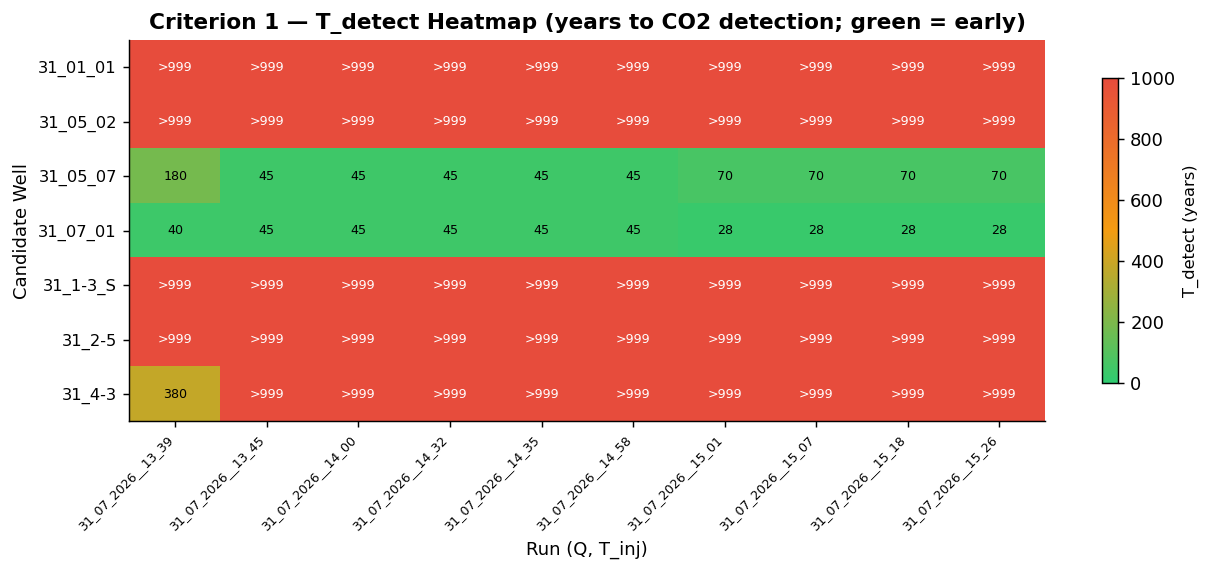

Score_1 (detection speed, 0-1, higher=better):
Well
31_01_01    0.000
31_05_02    0.000
31_05_07    0.968
31_07_01    1.000
31_1-3_S    0.000
31_2-5      0.000
31_4-3      0.064


In [62]:
# Score_1: normalize T_detect_mean ascending (lower = better = higher score)
tmean = tdet_df['T_detect_mean']
score1 = 1 - (tmean - tmean.min()) / (tmean.max() - tmean.min() + 1e-9)
score1 = score1.rename('Score_1_detection_speed')

# Heatmap of T_detect across all runs
run_cols = [c for c in tdet_df.columns if c not in ['T_detect_mean','T_detect_min']]
heat_data = tdet_df[run_cols].values.astype(float)

fig, ax = plt.subplots(figsize=(max(10, len(run_cols)*0.9), 4.5))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list('rg', ['#2ECC71','#F39C12','#E74C3C'])
im = ax.imshow(heat_data, aspect='auto', cmap=cmap, vmin=0, vmax=1000)
ax.set_xticks(range(len(run_cols)))
ax.set_xticklabels(run_cols, fontsize=7, rotation=45, ha='right')
ax.set_yticks(range(len(CANDIDATES)))
ax.set_yticklabels(tdet_df.index.tolist(), fontsize=9)
for i in range(heat_data.shape[0]):
    for j in range(heat_data.shape[1]):
        v = heat_data[i, j]
        txt = f'{v:.0f}' if v < 1000 else '>999'
        ax.text(j, i, txt, ha='center', va='center', fontsize=7,
                color='white' if v > 400 else 'black')
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('T_detect (years)', fontsize=9)
ax.set_title('Criterion 1 — T_detect Heatmap (years to CO2 detection; green = early)', fontsize=12, fontweight='bold')
ax.set_xlabel('Run (Q, T_inj)', fontsize=10); ax.set_ylabel('Candidate Well', fontsize=10)
plt.tight_layout(); plt.show()
print(f'Score_1 (detection speed, 0-1, higher=better):\n{score1.round(3).to_string()}')

## Section 3 — Criterion 2: Pressure Signal Strength (Detectability)

**Physical rationale:** Pressure fronts propagate much faster than the CO2 plume itself
(essentially instantaneous on reservoir timescales). A well showing a strong pressure anomaly
above baseline is operationally useful long before CO2 physically arrives.

For each well, `ΔP_max` = max pressure rise above baseline (t=1 yr) across all layers
and all timesteps during injection. We average this over all BO runs.

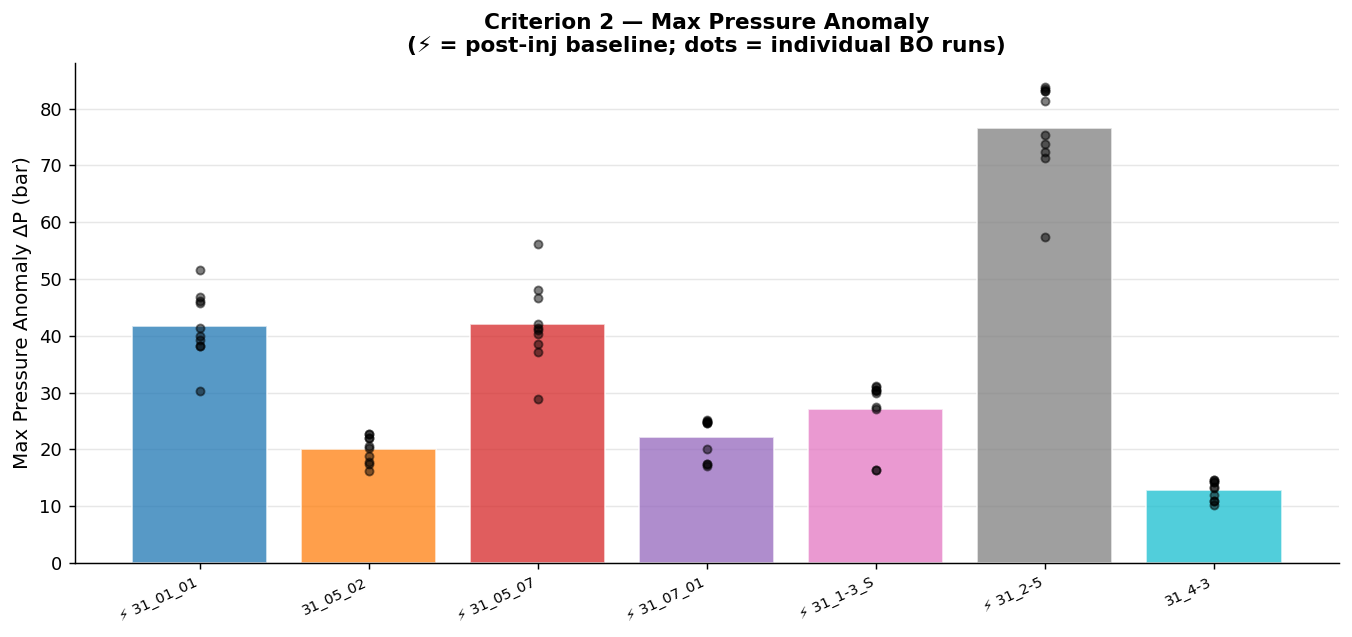

Score_2 (pressure signal, 0-1, higher=better):
31_01_01    0.454
31_05_02    0.114
31_05_07    0.459
31_07_01    0.146
31_1-3_S    0.223
31_2-5      1.000
31_4-3      0.000


In [63]:
def compute_delta_P(df, post_inj_yr=None):
    """
    Compute max pressure anomaly.
    post_inj_yr: For injectors, use injection-end pressure as baseline;
                 evaluate delta-P in post-injection period only.
    For monitors: use t=0 pressure as baseline over entire simulation.
    """
    if df is None or df.empty or 'Time_yr' not in df.columns: return 0.0
    cols = [c for c in PRE_COLS if c in df.columns]
    if not cols: return 0.0
    if post_inj_yr is not None:
        idx_end = (df['Time_yr'] - post_inj_yr).abs().idxmin()
        baseline = df.loc[idx_end, cols]   # pressure at injection end
        mask = df['Time_yr'] > post_inj_yr
        if not mask.any(): return 0.0
        dP = (df.loc[mask, cols] - baseline).abs().max().max()  # abs: detect both buildup & depletion
    else:
        baseline = df[cols].iloc[0]
        dP = (df[cols] - baseline).max().max()
    return float(dP) if not np.isnan(dP) else 0.0

dp_by_run = {w: [] for w in CANDIDATES}
for r in ALL_RUNS:
    for w in CANDIDATES:
        post_inj = get_post_inj_yr(r, w)
        dp_by_run[w].append(compute_delta_P(r['wells'].get(w), post_inj_yr=post_inj))

dp_mean = {w: float(np.mean(dp_by_run[w])) for w in CANDIDATES}
score2_raw = pd.Series(dp_mean)
score2 = (score2_raw - score2_raw.min()) / (score2_raw.max() - score2_raw.min() + 1e-9)
score2 = score2.rename('Score_2_pressure_signal')

# Grouped bar + scatter
x = np.arange(len(CANDIDATES))
fig, ax = plt.subplots(figsize=(max(10, len(CANDIDATES)*1.5), 5))
colors = plt.cm.tab10(np.linspace(0, 0.9, len(CANDIDATES)))
bars = ax.bar(x, [dp_mean[w] for w in CANDIDATES], color=colors, alpha=0.75, edgecolor='white', zorder=2)
for i, w in enumerate(CANDIDATES):
    for val in dp_by_run[w]:
        ax.scatter(i, val, color='black', s=20, zorder=4, alpha=0.5)
lbl = [('⚡ ' if is_injector(w) else '') + w for w in CANDIDATES]
ax.set_xticks(x); ax.set_xticklabels(lbl, fontsize=8, rotation=25, ha='right')
ax.set_ylabel('Max Pressure Anomaly ΔP (bar)', fontsize=11)
ax.set_title('Criterion 2 — Max Pressure Anomaly\n(⚡ = post-inj baseline; dots = individual BO runs)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y', zorder=1)
plt.tight_layout(); plt.show()
print(f'Score_2 (pressure signal, 0-1, higher=better):\n{score2.round(3).to_string()}')


## Section 4 — Criterion 3: Layer of First Detection (Buoyancy Sensitivity)

**Physical rationale:** CO2 rises buoyantly into shallower layers first
(L6 = shallowest). A well that detects CO2 in L6 or L7 is intercepting the gravitationally
driven plume tip — the most physically meaningful signal for early escape risk.

For each run where CO2 is detected, we record which layer first exceeds `S_DETECTION_THRESHOLD`.
Layer scoring: L6=5, L7=4, L8=3, L9=2, L10=1. Higher score = better buoyancy sensitivity.

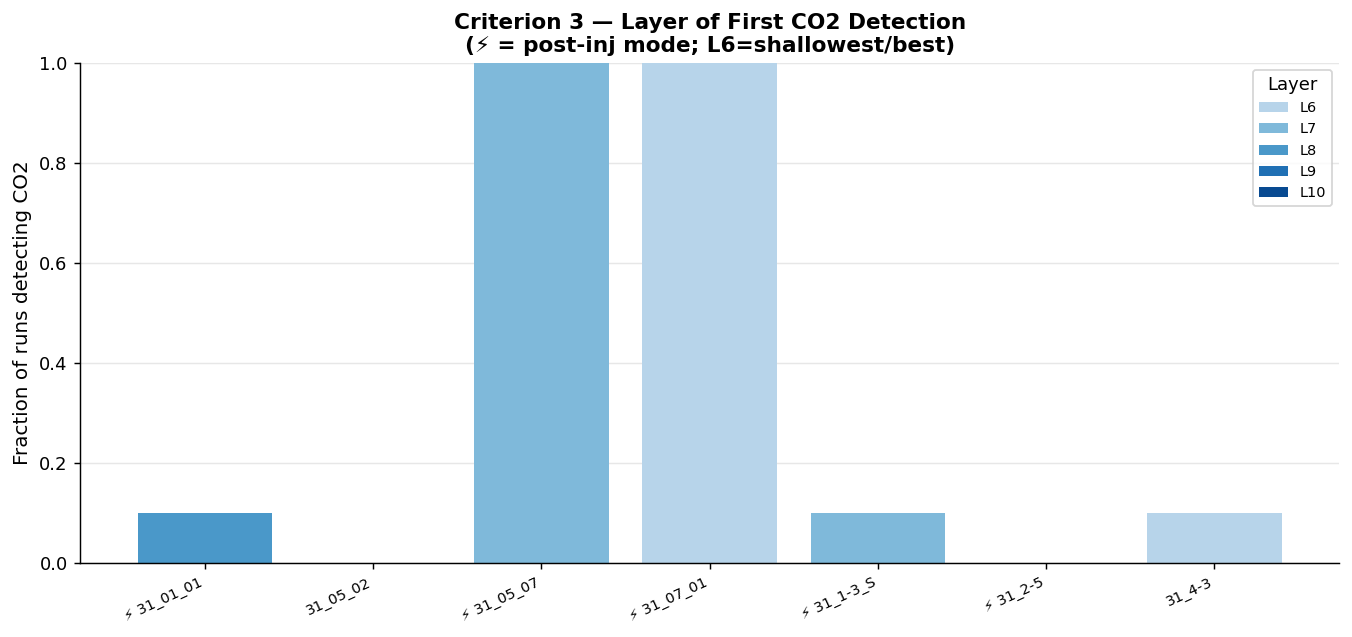

Score_3 (buoyancy, 0-1, higher=better):
31_01_01    0.6
31_05_02    0.0
31_05_07    0.8
31_07_01    1.0
31_1-3_S    0.8
31_2-5      0.0
31_4-3      1.0


In [64]:
layer_tallies   = {w: {k: 0 for k in LAYERS} for w in CANDIDATES}
buoyancy_scores = {w: [] for w in CANDIDATES}

for r in ALL_RUNS:
    for w in CANDIDATES:
        df = r['wells'].get(w)
        if df is None or df.empty: continue
        sat_cols = [c for c in SAT_COLS if c in df.columns]
        if not sat_cols: continue
        post_inj = get_post_inj_yr(r, w)
        if post_inj is not None:
            sub = df[df['Time_yr'] > post_inj]
            if sub.empty: continue
            # Detect first layer where external CO2 arrives (saturation rises above post-inj floor)
            baseline_s = sub[sat_cols].iloc[0]
            rise = (sub[sat_cols] - baseline_s).max()
            if rise.max() < S_DETECTION_THRESHOLD: continue
            first_layer_col = rise.idxmax()
        else:
            mx = df[sat_cols].max()
            if mx.max() < S_DETECTION_THRESHOLD: continue
            first_layer_col = mx.idxmax()
        lnum = int(first_layer_col.split('_L')[1])
        layer_tallies[w][lnum] += 1
        buoyancy_scores[w].append(max(LAYERS) + 1 - lnum)

# Score: higher layer number = shallower = better buoyancy sensitivity
buoy_mean = {}
for w in CANDIDATES:
    buoy_mean[w] = float(np.mean(buoyancy_scores[w])) if buoyancy_scores[w] else 0.0

score3_raw = pd.Series(buoy_mean)
score3 = (score3_raw - score3_raw.min()) / (score3_raw.max() - score3_raw.min() + 1e-9)
score3 = score3.rename('Score_3_buoyancy')

# Stacked bar: layer distribution
n_total = len(ALL_RUNS)
bottoms = np.zeros(len(CANDIDATES))
x = np.arange(len(CANDIDATES))
fig, ax = plt.subplots(figsize=(max(10, len(CANDIDATES)*1.5), 5))
layer_colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(LAYERS)))
for ki, k in enumerate(LAYERS):
    vals = np.array([layer_tallies[w][k] / max(n_total, 1) for w in CANDIDATES])
    ax.bar(x, vals, bottom=bottoms, color=layer_colors[ki], label=f'L{k}', zorder=2)
    bottoms += vals
lbl = [('⚡ ' if is_injector(w) else '') + w for w in CANDIDATES]
ax.set_xticks(x); ax.set_xticklabels(lbl, fontsize=8, rotation=25, ha='right')
ax.set_ylabel('Fraction of runs detecting CO2', fontsize=11)
ax.set_title('Criterion 3 — Layer of First CO2 Detection\n(⚡ = post-inj mode; L6=shallowest/best)', fontsize=12, fontweight='bold')
ax.legend(title='Layer', fontsize=8, loc='upper right')
ax.grid(True, alpha=0.3, axis='y', zorder=1)
plt.tight_layout(); plt.show()
print(f'Score_3 (buoyancy, 0-1, higher=better):\n{score3.round(3).to_string()}')


## Section 5 — Criterion 4: Signal Consistency Across Injection Rates (Robustness)

**Physical rationale:** A surveillance well must be useful across a realistic range of
operating conditions — not only at extreme injection rates.

We count how many of the BO runs produce a detection within 1000 yr (`N_detections`).
We also compute the coefficient of variation (CV = std/mean) of `T_detect` for detected runs —
low CV means the well gives a consistent, predictable response regardless of Q.

`Score_4 = 0.7 × N_detections_normalized + 0.3 × (1 − CV_normalized)`

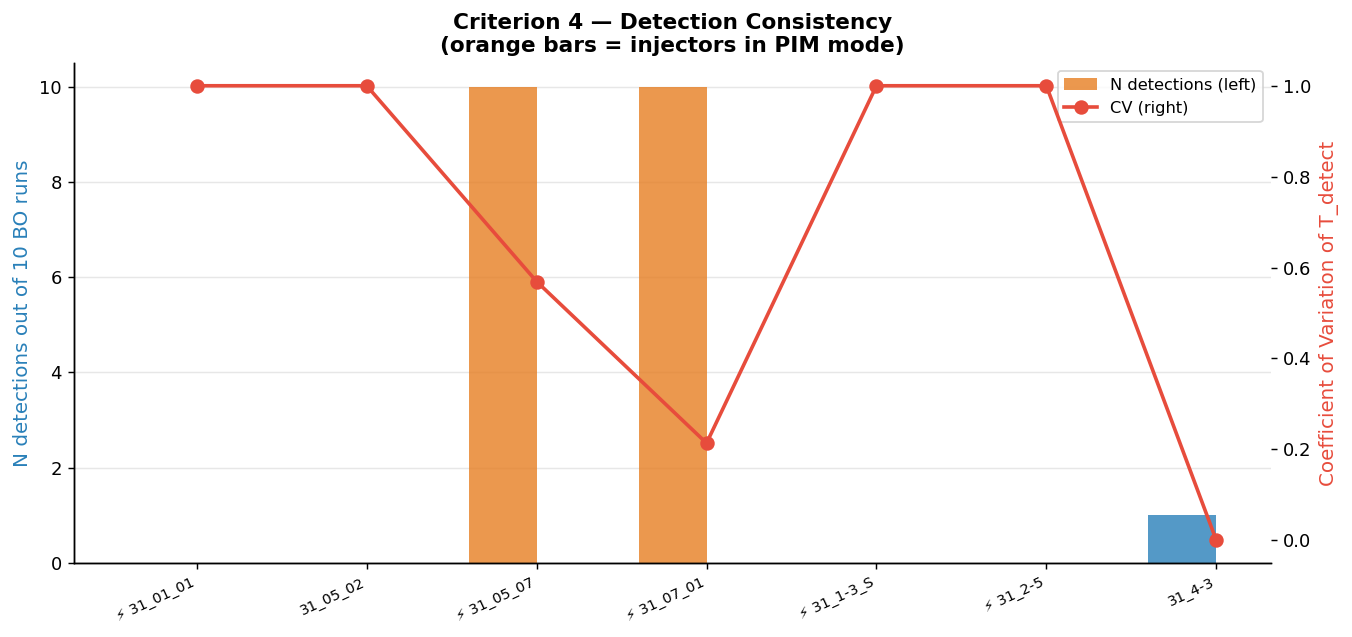

Score_4 (consistency, 0-1, higher=better):
31_01_01    0.000
31_05_02    0.000
31_05_07    0.829
31_07_01    0.936
31_1-3_S    0.000
31_2-5      0.000
31_4-3      0.370


In [65]:
n_detect  = {}
cv_detect = {}
for w in CANDIDATES:
    t_vals = []
    for r in ALL_RUNS:
        post_inj = get_post_inj_yr(r, w)
        t_vals.append(find_T_detect(r['wells'].get(w), post_inj_yr=post_inj))
    detected = [v for v in t_vals if v < 1000]
    n_detect[w] = len(detected)
    if len(detected) > 1:
        cv_detect[w] = float(np.std(detected) / (np.mean(detected) + 1e-9))
    elif len(detected) == 1:
        cv_detect[w] = 0.0
    else:
        cv_detect[w] = 1.0  # worst: no detection

n_s = pd.Series(n_detect, dtype=float)
cv_s = pd.Series(cv_detect, dtype=float)
n_norm  = (n_s  - n_s.min())  / (n_s.max()  - n_s.min()  + 1e-9)
cv_norm = (cv_s - cv_s.min()) / (cv_s.max() - cv_s.min() + 1e-9)
score4 = 0.7 * n_norm + 0.3 * (1 - cv_norm)
score4 = score4.rename('Score_4_consistency')

# Dual-axis bar + line
x = np.arange(len(CANDIDATES))
fig, ax1 = plt.subplots(figsize=(max(10, len(CANDIDATES)*1.5), 5))
ax2 = ax1.twinx()
bar_colors = ['#E67E22' if is_injector(w) else '#2980B9' for w in CANDIDATES]
ax1.bar(x - 0.2, [n_detect[w] for w in CANDIDATES], width=0.4,
        color=bar_colors, alpha=0.8, label='N detections (left)', zorder=2)
ax2.plot(x, [cv_detect[w] for w in CANDIDATES], 'o-', color='#E74C3C',
         linewidth=2, markersize=7, label='CV (right)')
lbl = [('⚡ ' if is_injector(w) else '') + w for w in CANDIDATES]
ax1.set_xticks(x); ax1.set_xticklabels(lbl, fontsize=8, rotation=25, ha='right')
ax1.set_ylabel(f'N detections out of {len(ALL_RUNS)} BO runs', fontsize=11, color='#2980B9')
ax2.set_ylabel('Coefficient of Variation of T_detect', fontsize=11, color='#E74C3C')
ax1.set_title('Criterion 4 — Detection Consistency\n(orange bars = injectors in PIM mode)', fontsize=12, fontweight='bold')
lines1, lab1 = ax1.get_legend_handles_labels()
lines2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, lab1+lab2, fontsize=9, loc='upper right')
ax1.grid(True, alpha=0.3, axis='y', zorder=1)
plt.tight_layout(); plt.show()
print(f'Score_4 (consistency, 0-1, higher=better):\n{score4.round(3).to_string()}')


## Section 6 — Criterion 5: Structural Position / Updip Proximity

**Physical rationale:** In the northward-dipping Johansen formation, CO2 migrates updip
toward shallower depths. A shallower well is structurally positioned along the primary
migration pathway and intercepts the plume before it reaches the formation boundary.

Shallower depth (lower absolute depth in metres) = closer to CO2 migration terminus
= structurally better surveillance position.

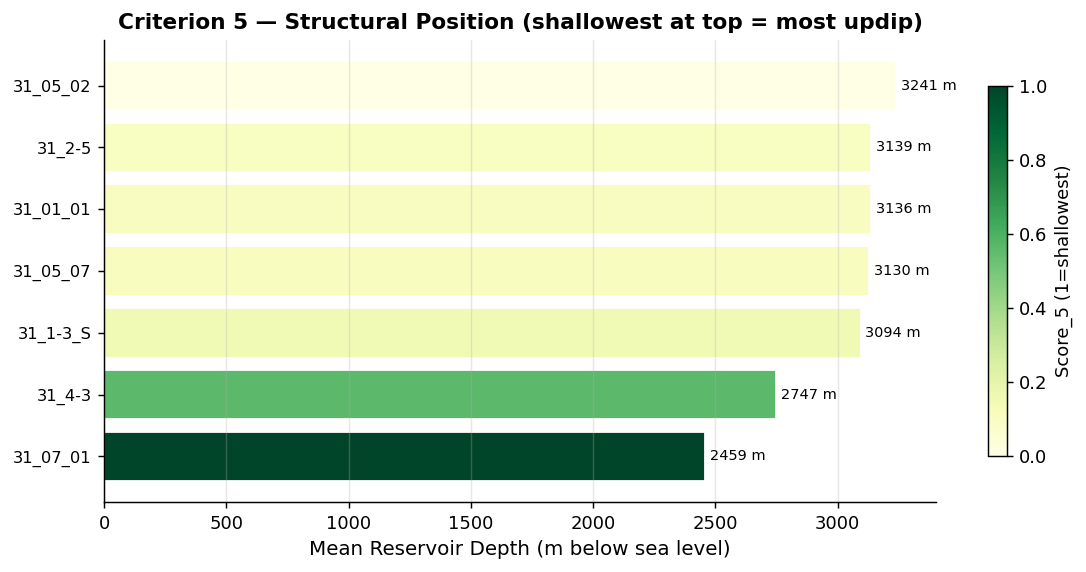

Score_5 (structural position, 0-1, higher=better):
31_01_01    0.106
31_05_02    0.000
31_05_07    0.111
31_07_01    1.000
31_1-3_S    0.149
31_2-5      0.102
31_4-3      0.565


In [66]:
depth_s = pd.Series(well_depths).reindex(CANDIDATES)
# Inverse: shallower = higher score
inv_depth = 1.0 / (depth_s + 1e-3)
score5 = (inv_depth - inv_depth.min()) / (inv_depth.max() - inv_depth.min() + 1e-9)
score5 = score5.rename('Score_5_structural_position')

# Horizontal bar sorted by depth
sorted_cands = depth_s.sort_values().index.tolist()
sorted_depths = depth_s[sorted_cands].values
sorted_scores = score5[sorted_cands].values
cmap5 = plt.cm.YlGn
bar_colors = cmap5(sorted_scores)

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(range(len(sorted_cands)), sorted_depths, color=bar_colors, edgecolor='white')
ax.set_yticks(range(len(sorted_cands)))
ax.set_yticklabels(sorted_cands, fontsize=9)
for i, (bar, d) in enumerate(zip(bars, sorted_depths)):
    ax.text(d + 20, i, f'{d:.0f} m', va='center', fontsize=8)
ax.set_xlabel('Mean Reservoir Depth (m below sea level)', fontsize=11)
ax.set_title('Criterion 5 — Structural Position (shallowest at top = most updip)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
sm = plt.cm.ScalarMappable(cmap=cmap5, norm=Normalize(0, 1))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Score_5 (1=shallowest)', shrink=0.8)
plt.tight_layout(); plt.show()
print(f'Score_5 (structural position, 0-1, higher=better):\n{score5.round(3).to_string()}')

## Section 7 — Composite Scoring & Recommendation

All five normalised scores (0–1, higher = better) are combined into a weighted composite.
The weights reflect the relative operational importance of each criterion.

**Output:** Scoring table, radar chart, ranked bar chart, and a plain-text recommendation.

In [67]:
# Assemble score DataFrame aligned to CANDIDATES
score_df = pd.DataFrame({
    'Score_1 (detection)': score1.reindex(CANDIDATES),
    'Score_2 (pressure)':  score2.reindex(CANDIDATES),
    'Score_3 (buoyancy)':  score3.reindex(CANDIDATES),
    'Score_4 (consistency)': score4.reindex(CANDIDATES),
    'Score_5 (position)':  score5.reindex(CANDIDATES),
}, index=CANDIDATES)

w = WEIGHTS
score_df['Composite_Score'] = (
    score_df['Score_1 (detection)']   * w['detection_speed'] +
    score_df['Score_2 (pressure)']    * w['pressure_signal'] +
    score_df['Score_3 (buoyancy)']    * w['buoyancy_layer'] +
    score_df['Score_4 (consistency)'] * w['consistency'] +
    score_df['Score_5 (position)']    * w['structural_position']
)
score_df = score_df.sort_values('Composite_Score', ascending=False)
best_well   = score_df.index[0]
runner_up   = score_df.index[1]

# Styled table
display(score_df.round(3).style.background_gradient(cmap='Greens',
        subset=['Score_1 (detection)','Score_2 (pressure)','Score_3 (buoyancy)',
                'Score_4 (consistency)','Score_5 (position)','Composite_Score']))

,Score_1 (detection),Score_2 (pressure),Score_3 (buoyancy),Score_4 (consistency),Score_5 (position),Composite_Score
31_07_01,1.000000,0.146000,1.000000,0.936000,1.000000,0.777000
31_05_07,0.968000,0.459000,0.800000,0.829000,0.111000,0.701000
31_4-3,0.064000,0.000000,1.000000,0.370000,0.565000,0.331000
31_2-5,0.000000,1.000000,0.000000,0.000000,0.102000,0.260000
31_01_01,0.000000,0.454000,0.600000,0.000000,0.106000,0.244000
31_1-3_S,0.000000,0.223000,0.800000,0.000000,0.149000,0.231000
31_05_02,0.000000,0.114000,0.000000,0.000000,0.000000,0.028000


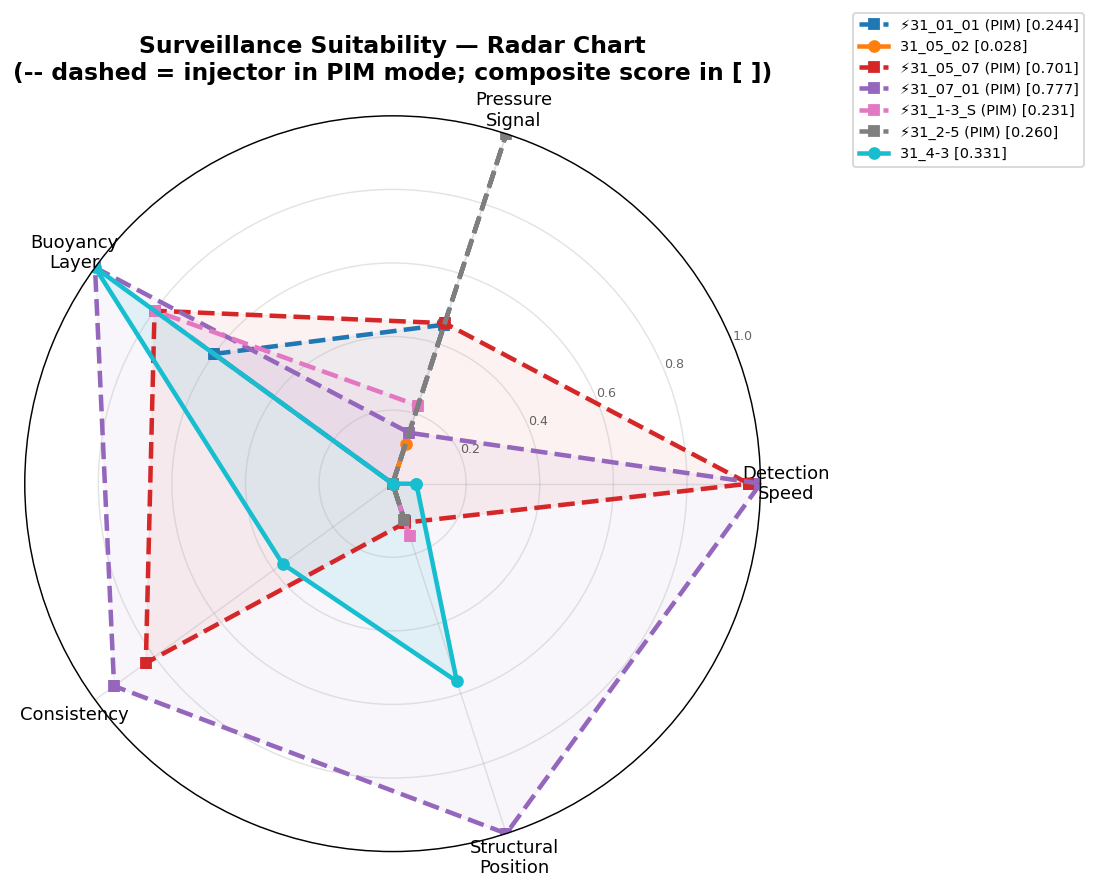

In [68]:
# ── Radar chart — ALL candidates (monitors + injectors in PIM mode) ─────────────
criteria_labels = ['Detection\nSpeed', 'Pressure\nSignal', 'Buoyancy\nLayer',
                   'Consistency', 'Structural\nPosition']
score_cols = ['Score_1 (detection)', 'Score_2 (pressure)', 'Score_3 (buoyancy)',
              'Score_4 (consistency)', 'Score_5 (position)']
N = len(criteria_labels)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
colors_palette = plt.cm.tab10(np.linspace(0, 0.9, len(CANDIDATES)))

for i, well in enumerate(CANDIDATES):
    vals = score_df.loc[well, score_cols].tolist()
    vals += vals[:1]
    comp = score_df.loc[well, 'Composite_Score']
    lw = 2.5
    ls = '--' if is_injector(well) else '-'
    marker = 's' if is_injector(well) else 'o'
    label = f'⚡{well} (PIM) [{comp:.3f}]' if is_injector(well) else f'{well} [{comp:.3f}]'
    ax.plot(angles, vals, linestyle=ls, marker=marker, color=colors_palette[i],
            linewidth=lw, markersize=6, label=label)
    ax.fill(angles, vals, alpha=0.06 if is_injector(well) else 0.10, color=colors_palette[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(criteria_labels, fontsize=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], fontsize=7, alpha=0.6)
ax.set_title('Surveillance Suitability — Radar Chart\n(-- dashed = injector in PIM mode; composite score in [ ])',
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.45, 1.15), fontsize=8)
ax.grid(True, alpha=0.35)
plt.tight_layout(); plt.show()


## Goal 2 — Sentinel Well Comparison

`SBoundary_test_well` and `SBoundary_test_well_2` are fictional wells added at the reservoir
boundary to detect CO2 before it escapes. They are NOT pre-existing drilled wells and are NOT
eligible for the surveillance recommendation above, but it is instructive to see how they score
on the same 5 criteria — as a theoretical reference for how well-positioned a purpose-built
sentinel would need to be.


Sentinel wells available in runs: ['SBoundary_test_well', 'SBoundary_test_well_2']


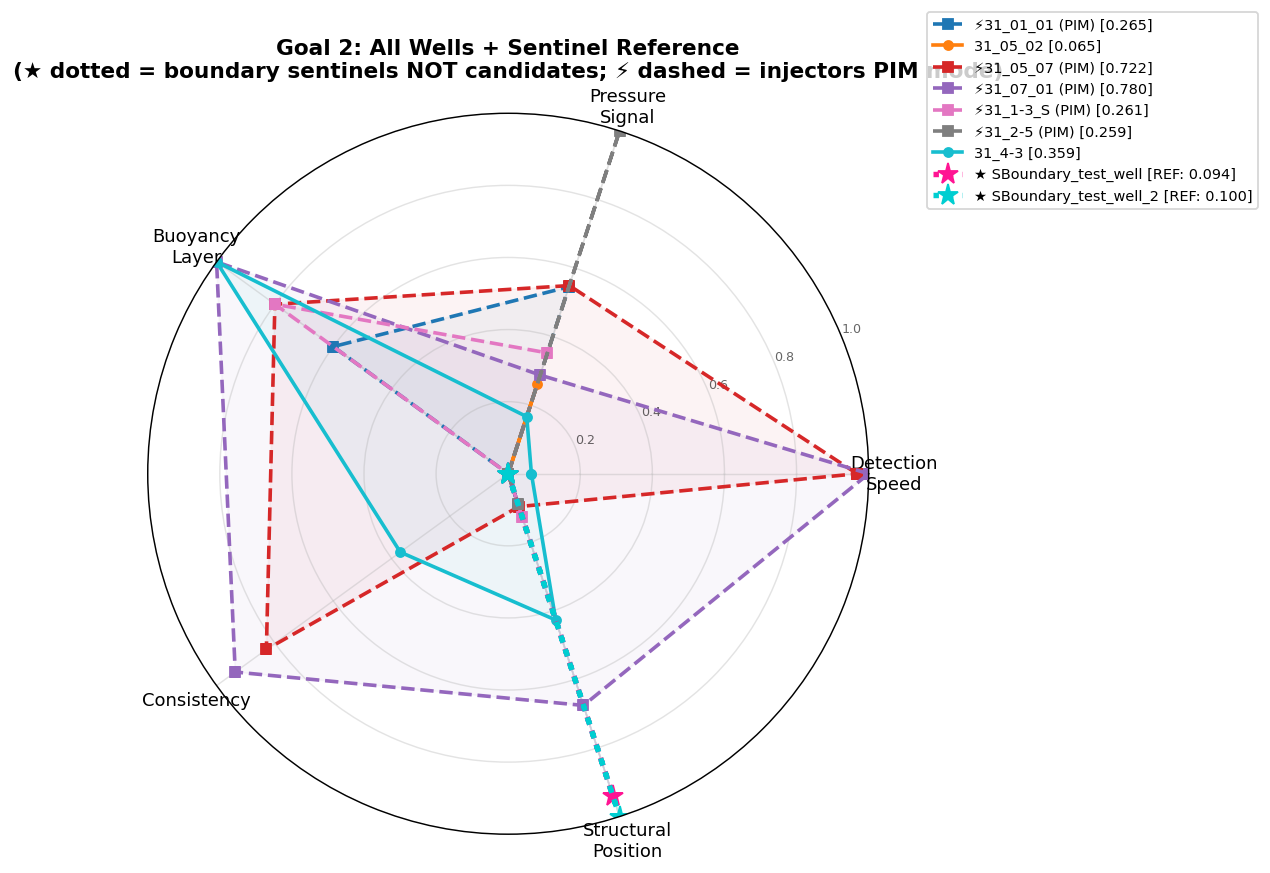


=== COMBINED RANKING (all wells + sentinels for reference) ===
  #1: 31_07_01                       score=0.7799 ⚡ INJECTOR→PIM
  #2: 31_05_07                       score=0.7216 ⚡ INJECTOR→PIM
  #3: 31_4-3                         score=0.3591
  #4: 31_01_01                       score=0.2654 ⚡ INJECTOR→PIM
  #5: 31_1-3_S                       score=0.2608 ⚡ INJECTOR→PIM
  #6: 31_2-5                         score=0.2588 ⚡ INJECTOR→PIM
  #7: SBoundary_test_well_2          score=0.1000 ★ SENTINEL (not a candidate)
  #8: SBoundary_test_well            score=0.0940 ★ SENTINEL (not a candidate)
  #9: 31_05_02                       score=0.0653


In [69]:
# ── Evaluate sentinel wells on same 5 criteria (pure monitor mode) ──────────────
SENTINEL_WELLS_LIST = ["SBoundary_test_well", "SBoundary_test_well_2"]

# Check they exist in at least one run
sentinels_available = [w for w in SENTINEL_WELLS_LIST
                       if any(w in r['wells'] for r in ALL_RUNS)]
print(f"Sentinel wells available in runs: {sentinels_available}")

if sentinels_available:
    # ── Criterion 1: T_detect (pure monitor, no post-inj adjustment)
    tdet_s = {}
    for w in sentinels_available:
        vals = [find_T_detect(r['wells'].get(w)) for r in ALL_RUNS]
        tdet_s[w] = float(np.mean(vals))

    # ── Criterion 2: Pressure anomaly
    dp_s = {}
    for w in sentinels_available:
        vals = [compute_delta_P(r['wells'].get(w)) for r in ALL_RUNS]
        dp_s[w] = float(np.mean(vals))

    # ── Criterion 3: Buoyancy layer
    buoy_s = {}
    for w in sentinels_available:
        scores = []
        for r in ALL_RUNS:
            df = r['wells'].get(w)
            if df is None or df.empty: continue
            sat_cols = [c for c in SAT_COLS if c in df.columns]
            if not sat_cols: continue
            mx = df[sat_cols].max()
            if mx.max() < S_DETECTION_THRESHOLD: continue
            lnum = int(mx.idxmax().split('_L')[1])
            scores.append(max(LAYERS) + 1 - lnum)
        buoy_s[w] = float(np.mean(scores)) if scores else 0.0

    # ── Criterion 4: Consistency
    n_det_s, cv_det_s = {}, {}
    for w in sentinels_available:
        tvals = [find_T_detect(r['wells'].get(w)) for r in ALL_RUNS]
        detected = [v for v in tvals if v < 1000]
        n_det_s[w] = len(detected)
        cv_det_s[w] = float(np.std(detected)/(np.mean(detected)+1e-9)) if len(detected) > 1 else (0.0 if detected else 1.0)

    # ── Criterion 5: Structural depth
    depth_s = {}
    for w in sentinels_available:
        dvals = []
        for r in ALL_RUNS:
            df = r['wells'].get(w)
            if df is not None and not df.empty:
                cols = [c for c in DEP_COLS if c in df.columns]
                if cols: dvals.append(df[cols].iloc[0].mean())
        depth_s[w] = float(np.mean(dvals)) if dvals else np.nan

    # ── Build combined score reference (normalize against CANDIDATE scores for fair comparison)
    # Extend each raw score series with sentinel values, renormalize
    all_tdet  = dict(zip(CANDIDATES, [tdet_df.loc[w,'T_detect_mean'] for w in CANDIDATES]))
    all_tdet.update(tdet_s)
    all_dp    = {**dp_mean, **dp_s}
    all_buoy  = {**buoy_mean, **buoy_s}
    all_ndets = {**n_detect, **n_det_s}
    all_cv    = {**cv_detect, **cv_det_s}
    all_depth = {**well_depths, **depth_s}
    ALL_WELLS = CANDIDATES + sentinels_available

    def norm01(d):
        s = pd.Series(d, dtype=float)
        return (s - s.min()) / (s.max() - s.min() + 1e-9)

    sc1 = norm01({w: -all_tdet[w] for w in ALL_WELLS})   # lower T_detect = better → negate
    sc2 = norm01(all_dp)
    sc3 = norm01(all_buoy)
    n_norm2  = norm01({w: all_ndets[w] for w in ALL_WELLS})
    cv_norm2 = norm01({w: all_cv[w]    for w in ALL_WELLS})
    sc4 = 0.7 * n_norm2 + 0.3 * (1 - cv_norm2)
    sc5 = norm01({w: -all_depth.get(w, 9999) for w in ALL_WELLS})  # shallower = better

    w = WEIGHTS
    comp_all = {well: (
        sc1[well]*w['detection_speed'] + sc2[well]*w['pressure_signal'] +
        sc3[well]*w['buoyancy_layer']  + sc4[well]*w['consistency']     +
        sc5[well]*w['structural_position']
    ) for well in ALL_WELLS}

    # ── Combined radar chart
    score_cols_all = [sc1, sc2, sc3, sc4, sc5]
    criteria_labels_r = ['Detection\nSpeed', 'Pressure\nSignal', 'Buoyancy\nLayer',
                         'Consistency', 'Structural\nPosition']
    N = len(criteria_labels_r)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist() + [0]

    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
    n_cands = len(CANDIDATES)
    cand_colors = plt.cm.tab10(np.linspace(0, 0.9, n_cands))
    sentinel_colors = ['#FF1493', '#00CED1']  # hot pink and dark turquoise for sentinels

    for i, well in enumerate(CANDIDATES):
        vals = [float(sc[well]) for sc in score_cols_all] + [float(sc1[well])]
        comp = comp_all[well]
        ls = '--' if is_injector(well) else '-'
        m  = 's'  if is_injector(well) else 'o'
        lbl = f'⚡{well} (PIM) [{comp:.3f}]' if is_injector(well) else f'{well} [{comp:.3f}]'
        ax.plot(angles, vals, linestyle=ls, marker=m, color=cand_colors[i],
                linewidth=2.0, markersize=5, label=lbl)
        ax.fill(angles, vals, alpha=0.05, color=cand_colors[i])

    for i, well in enumerate(sentinels_available):
        vals = [float(sc[well]) for sc in score_cols_all] + [float(sc1[well])]
        comp = comp_all[well]
        ax.plot(angles, vals, linestyle=':', marker='*', color=sentinel_colors[i],
                linewidth=3.0, markersize=12,
                label=f'★ {well} [REF: {comp:.3f}]')
        ax.fill(angles, vals, alpha=0.12, color=sentinel_colors[i])

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(criteria_labels_r, fontsize=10)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], fontsize=7, alpha=0.6)
    ax.set_title('Goal 2: All Wells + Sentinel Reference\n(★ dotted = boundary sentinels NOT candidates; ⚡ dashed = injectors PIM mode)',
                 fontsize=12, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.55, 1.15), fontsize=8)
    ax.grid(True, alpha=0.35)
    plt.tight_layout(); plt.show()

    print('\n=== COMBINED RANKING (all wells + sentinels for reference) ===')
    ranked = sorted(comp_all.items(), key=lambda x: -x[1])
    for rank, (well, score) in enumerate(ranked, 1):
        tag = ' ★ SENTINEL (not a candidate)' if well in sentinels_available else \
              ' ⚡ INJECTOR→PIM' if is_injector(well) else ''
        print(f'  #{rank}: {well:<30} score={score:.4f}{tag}')
else:
    print('Sentinel well data not available in current runs.')


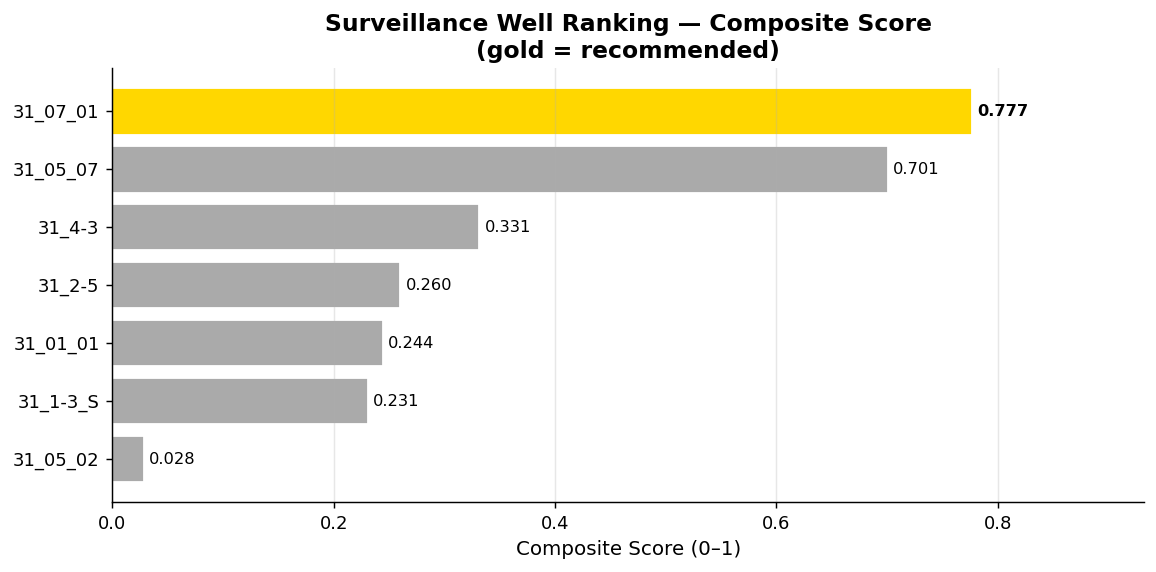

In [70]:
# ── Final ranked bar chart ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4.5))
ranked = score_df.sort_values('Composite_Score')
bar_c = ['gold' if w == best_well else '#AAAAAA' for w in ranked.index]
bars = ax.barh(range(len(ranked)), ranked['Composite_Score'], color=bar_c, edgecolor='white')
ax.set_yticks(range(len(ranked)))
ax.set_yticklabels(ranked.index.tolist(), fontsize=10)
for i, (bar, val) in enumerate(zip(bars, ranked['Composite_Score'])):
    ax.text(bar.get_width() + 0.005, i, f'{val:.3f}', va='center', fontsize=9,
            fontweight='bold' if ranked.index[i] == best_well else 'normal')
ax.set_xlabel('Composite Score (0–1)', fontsize=11)
ax.set_title('Surveillance Well Ranking — Composite Score\n(gold = recommended)', fontsize=13, fontweight='bold')
ax.set_xlim(0, ranked['Composite_Score'].max() * 1.2)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout(); plt.show()

In [71]:
# ── Plain-text recommendation ─────────────────────────────────────
best_scores = score_df.loc[best_well]
runner_scores = score_df.loc[runner_up]
t_det_mean = tdet_df.loc[best_well, 'T_detect_mean']
dp_val     = dp_mean[best_well]
best_layer_tally = layer_tallies[best_well]
best_first_layer = max(best_layer_tally, key=lambda k: best_layer_tally[k])
det_n = n_detect[best_well]
best_depth = well_depths[best_well]

# depth rank
depth_rank = sorted(CANDIDATES, key=lambda w: well_depths.get(w, 9999)).index(best_well) + 1
t_det_rank = sorted(CANDIDATES, key=lambda w: tdet_df.loc[w,'T_detect_mean']).index(best_well) + 1
dp_rank = sorted(CANDIDATES, key=lambda w: dp_mean.get(w,0), reverse=True).index(best_well) + 1

phys_interp = (
    f"{best_well} sits at {best_depth:.0f} m depth — rank #{depth_rank} shallowest among candidates — "
    f"placing it along the updip CO2 migration pathway in the northward-dipping Johansen formation. "
    f"Its pressure front arrives early (mean detection at {t_det_mean:.0f} yr), and it detects CO2 "
    f"most frequently in layer L{best_first_layer}, consistent with buoyancy-driven plume rise into "
    f"the shallowest permeable intervals. Across all tested injection rates ({det_n}/{len(ALL_RUNS)} runs produce "
    f"a detection), it provides the most reliable operational signal."
)

bar = '=' * 52
print(f'''
{bar}
  SURVEILLANCE WELL RECOMMENDATION
{bar}
  Recommended well   : {best_well}
  Composite score    : {best_scores['Composite_Score']:.4f}
  Runner-up          : {runner_up} (score: {runner_scores['Composite_Score']:.4f})

  Primary reasons:
    * Earliest mean CO2 detection : {t_det_mean:.0f} yr   (Rank #{t_det_rank})
    * Pressure signal strength    : {dp_val:.2f} bar (Rank #{dp_rank})
    * Most-frequent first detect  : L{best_first_layer} in {best_layer_tally[best_first_layer]}/{len(ALL_RUNS)} runs
    * Detects across {det_n}/{len(ALL_RUNS)} injection scenarios tested
    * Structural depth            : {best_depth:.0f} m (Rank #{depth_rank} shallowest)

  Physical interpretation:
    {phys_interp}
{bar}
''')


  SURVEILLANCE WELL RECOMMENDATION
  Recommended well   : 31_07_01
  Composite score    : 0.7768
  Runner-up          : 31_05_07 (score: 0.7006)

  Primary reasons:
    * Earliest mean CO2 detection : 38 yr   (Rank #1)
    * Pressure signal strength    : 22.09 bar (Rank #5)
    * Most-frequent first detect  : L6 in 10/10 runs
    * Detects across 10/10 injection scenarios tested
    * Structural depth            : 2459 m (Rank #1 shallowest)

  Physical interpretation:
    31_07_01 sits at 2459 m depth — rank #1 shallowest among candidates — placing it along the updip CO2 migration pathway in the northward-dipping Johansen formation. Its pressure front arrives early (mean detection at 38 yr), and it detects CO2 most frequently in layer L6, consistent with buoyancy-driven plume rise into the shallowest permeable intervals. Across all tested injection rates (10/10 runs produce a detection), it provides the most reliable operational signal.



## Section 8 — Sensitivity Check: Does the Recommendation Hold?

We re-run the composite scoring under four weight schemes:
- **Original** — as configured above
- **(a) Detection-dominated** — 0.6 / 0.1 / 0.1 / 0.1 / 0.1
- **(b) Pressure-dominated** — 0.1 / 0.6 / 0.1 / 0.1 / 0.1
- **(c) Equal weights** — 0.2 each

If the same well wins all four schemes → **robustly optimal**.
If it changes → identify which criterion is the swing factor.

In [72]:
alt_schemes = {
    'Original': WEIGHTS,
    '(a) Detection-dominated': {'detection_speed':0.60,'pressure_signal':0.10,'buoyancy_layer':0.10,'consistency':0.10,'structural_position':0.10},
    '(b) Pressure-dominated':  {'detection_speed':0.10,'pressure_signal':0.60,'buoyancy_layer':0.10,'consistency':0.10,'structural_position':0.10},
    '(c) Equal weights':       {'detection_speed':0.20,'pressure_signal':0.20,'buoyancy_layer':0.20,'consistency':0.20,'structural_position':0.20},
}

sens_rows = []
for scheme_name, wts in alt_schemes.items():
    comp = (
        score_df['Score_1 (detection)']    * wts['detection_speed'] +
        score_df['Score_2 (pressure)']     * wts['pressure_signal'] +
        score_df['Score_3 (buoyancy)']     * wts['buoyancy_layer'] +
        score_df['Score_4 (consistency)']  * wts['consistency'] +
        score_df['Score_5 (position)']     * wts['structural_position']
    )
    winner = comp.idxmax()
    runner = comp.drop(index=winner).idxmax()
    sens_rows.append({'Weight Scheme': scheme_name,
                      'Recommended': winner,
                      'Score': f'{comp[winner]:.4f}',
                      'Runner-up': runner,
                      'Stable?': '✅ YES' if winner == best_well else f'❌ Changed to {winner}'})

sens_df = pd.DataFrame(sens_rows)
display(sens_df)

all_winners = [r['Recommended'] for r in sens_rows]
if len(set(all_winners)) == 1:
    print(f'\n>>> ROBUSTLY OPTIMAL: {best_well} wins under all {len(all_winners)} weight schemes.')
    print('    The recommendation is insensitive to subjective weight choices.')
else:
    unique_winners = set(all_winners)
    swing = [s for s in alt_schemes if sens_rows[list(alt_schemes.keys()).index(s)]['Recommended'] != best_well]
    print(f'\n>>> SENSITIVE: The recommendation changes under {swing}')
    print(f'    Wells competing: {unique_winners}')
    print('    Review the weights — the swing criterion may require expert elicitation.')

,Weight Scheme,Recommended,Score,Runner-up,Stable?
0,Original,31_07_01,0.7768,31_05_07,✅ YES
1,(a) Detection-dominated,31_07_01,0.9081,31_05_07,✅ YES
2,(b) Pressure-dominated,31_2-5,0.6102,31_05_07,❌ Changed to 31_2-5
3,(c) Equal weights,31_07_01,0.8163,31_05_07,✅ YES



>>> SENSITIVE: The recommendation changes under ['(b) Pressure-dominated']
    Wells competing: {'31_2-5', '31_07_01'}
    Review the weights — the swing criterion may require expert elicitation.


## Summary

This notebook applied five physically motivated criteria to rank six candidate surveillance wells
for the Johansen CO2 storage project:

| Criterion | Weight | Physical basis |
|---|---|---|
| 1. Earliest CO2 detection | 30% | Allows earliest operational response |
| 2. Pressure signal strength | 25% | Pressure fronts arrive before CO2 plume |
| 3. Buoyancy-driven layer detection | 20% | Upper-layer detection = plume tip intercept |
| 4. Consistency across Q | 15% | Operational reliability across rate scenarios |
| 5. Structural depth position | 10% | Updip position = along migration pathway |

The **Section 8 sensitivity check** tests whether the top-ranked well holds its position
when weights are varied — a robustly optimal recommendation requires stability across at
least three of the four schemes.